# Calibration Comparison: FFT vs GP vs Sparse GP

Compare three Heston calibrations — the direct FFT-pricer calibration, the exact GP-emulator calibration, and the sparse GP-emulator calibration. The notebook reports parameter closeness, fit quality, wall-clock time, and one fitted volatility smile across all three methods.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PARAMETER_COLUMNS = ["v0", "kappa", "theta", "sigma_v", "rho"]

## Settings

In [2]:
GP_DIR = Path("outputs/gp_calibration")
FFT_DIR = Path("outputs/fft_calibration")
SPARSE_GP_DIR = Path("outputs/sparse_gp_calibration")
OUTPUT_DIR = Path("outputs/calibration_comparison_3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GP_SUMMARY_PATH = GP_DIR / "calibration_summary.csv"
FFT_SUMMARY_PATH = FFT_DIR / "calibration_summary.csv"
SPARSE_GP_SUMMARY_PATH = SPARSE_GP_DIR / "calibration_summary.csv"
GP_PREDICTIONS_PATH = GP_DIR / "calibration_predictions.csv"
FFT_PREDICTIONS_PATH = FFT_DIR / "calibration_predictions.csv"
SPARSE_GP_PREDICTIONS_PATH = SPARSE_GP_DIR / "calibration_predictions.csv"

## Load Results

In [3]:
# Load the saved outputs from the three calibration notebooks.
gp_summary = pd.read_csv(GP_SUMMARY_PATH).iloc[0]
fft_summary = pd.read_csv(FFT_SUMMARY_PATH).iloc[0]
sparse_gp_summary = pd.read_csv(SPARSE_GP_SUMMARY_PATH).iloc[0]

gp_predictions = pd.read_csv(GP_PREDICTIONS_PATH)
fft_predictions = pd.read_csv(FFT_PREDICTIONS_PATH)
sparse_gp_predictions = pd.read_csv(SPARSE_GP_PREDICTIONS_PATH)

## 1 Parameter Comparison

In [4]:
# Compare fitted Heston parameters side by side across the three methods.
parameter_table = pd.DataFrame({
    "parameter": PARAMETER_COLUMNS,
    "fft_calibrated": [fft_summary[column] for column in PARAMETER_COLUMNS],
    "gp_calibrated": [gp_summary[column] for column in PARAMETER_COLUMNS],
    "sparse_gp_calibrated": [sparse_gp_summary[column] for column in PARAMETER_COLUMNS],
})

# With three methods, summarise divergence as the spread (max - min) per parameter.
method_columns = ["fft_calibrated", "gp_calibrated", "sparse_gp_calibrated"]
parameter_table["max_abs_spread"] = (
    parameter_table[method_columns].max(axis=1) - parameter_table[method_columns].min(axis=1)
)
mean_magnitude = parameter_table[method_columns].abs().mean(axis=1)
parameter_table["relative_spread_pct"] = np.where(
    mean_magnitude > 1e-12,
    100.0 * parameter_table["max_abs_spread"] / mean_magnitude,
    np.nan,
)

parameter_table.to_csv(OUTPUT_DIR / "parameter_comparison.csv", index=False)
parameter_table

,parameter,fft_calibrated,gp_calibrated,sparse_gp_calibrated,max_abs_spread,relative_spread_pct
0,v0,0.036020,0.033038,0.032526,0.003493,10.316851
1,kappa,2.650961,4.998386,0.100106,4.898280,189.624224
2,theta,0.010123,0.117082,0.141980,0.131857,146.951326
3,sigma_v,0.999386,0.999386,0.999386,0.000000,0.000000
4,rho,-0.949577,-0.949577,-0.949577,0.000000,0.000000


## Parameter Visualization

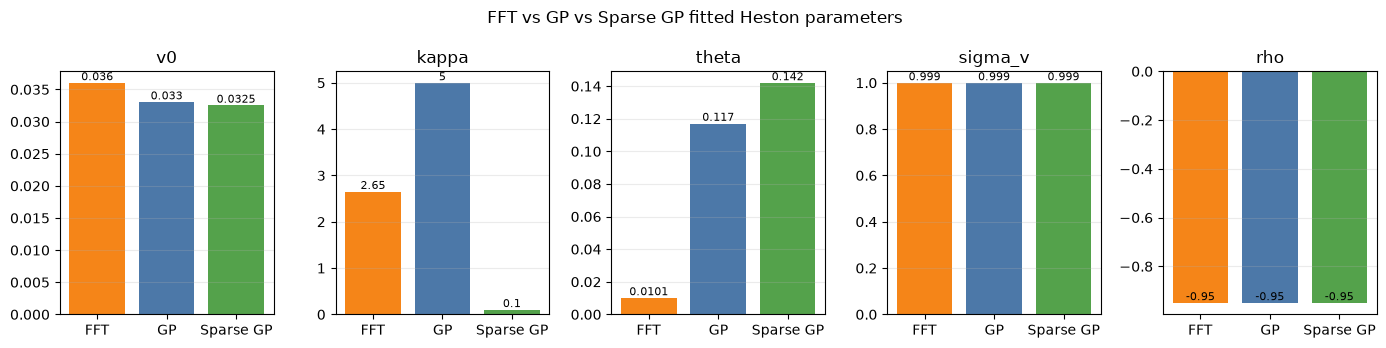

Saved plot to outputs/calibration_comparison_3/parameter_small_multiples.png


In [5]:
# Use one y-axis per parameter so small-scale parameters stay visible.
fig, axes = plt.subplots(1, len(PARAMETER_COLUMNS), figsize=(14, 3.5))

method_labels = ["FFT", "GP", "Sparse GP"]
method_colors = ["#F58518", "#4C78A8", "#54A24B"]

for ax, row in zip(axes, parameter_table.itertuples(index=False)):
    values = [row.fft_calibrated, row.gp_calibrated, row.sparse_gp_calibrated]
    ax.bar(method_labels, values, color=method_colors)
    ax.set_title(row.parameter)
    ax.grid(axis="y", alpha=0.25)
    for i, value in enumerate(values):
        ax.text(i, value, f"{value:.3g}", ha="center", va="bottom", fontsize=8)

fig.suptitle("FFT vs GP vs Sparse GP fitted Heston parameters")
fig.tight_layout()

parameter_plot_path = OUTPUT_DIR / "parameter_small_multiples.png"
fig.savefig(parameter_plot_path, dpi=180)
plt.show()

print(f"Saved plot to {parameter_plot_path}")

## Parameter Discussion

In [6]:
# Summarize where the three calibrations agree or diverge most.
closest = parameter_table.loc[parameter_table["max_abs_spread"].idxmin()]
furthest = parameter_table.loc[parameter_table["max_abs_spread"].idxmax()]

print(
    f"The most consistent parameter across methods is {closest.parameter}, with a spread of "
    f"{closest.max_abs_spread:.4g}. The largest disagreement is in {furthest.parameter}, where "
    f"FFT={furthest.fft_calibrated:.4g}, GP={furthest.gp_calibrated:.4g}, and "
    f"Sparse GP={furthest.sparse_gp_calibrated:.4g}. "
    "The small-multiple plots are useful here because each parameter has a different natural scale."
)

The most consistent parameter across methods is sigma_v, with a spread of 0. The largest disagreement is in kappa, where FFT=2.651, GP=4.998, and Sparse GP=0.1001. The small-multiple plots are useful here because each parameter has a different natural scale.


## 2 Error Comparison

In [7]:
# Compare fit quality using the metrics saved by each calibration notebook.
error_table = pd.DataFrame([
    {
        "method": "FFT pricer",
        "total_calibration_error": fft_summary["total_calibration_error"],
        "rmse": fft_summary["rmse"],
        "mae": fft_summary["mae"],
        "contracts": int(fft_summary["contracts"]),
        "success": bool(fft_summary["success"]),
    },
    {
        "method": "GP emulator",
        "total_calibration_error": gp_summary["total_calibration_error"],
        "rmse": gp_summary["rmse"],
        "mae": gp_summary["mae"],
        "contracts": int(gp_summary["contracts"]),
        "success": bool(gp_summary["success"]),
    },
    {
        "method": "Sparse GP emulator",
        "total_calibration_error": sparse_gp_summary["total_calibration_error"],
        "rmse": sparse_gp_summary["rmse"],
        "mae": sparse_gp_summary["mae"],
        "contracts": int(sparse_gp_summary["contracts"]),
        "success": bool(sparse_gp_summary["success"]),
    },
])

error_table.to_csv(OUTPUT_DIR / "error_comparison.csv", index=False)
error_table

,method,total_calibration_error,rmse,mae,contracts,success
0,FFT pricer,17.649008,0.134680,0.089626,973,True
1,GP emulator,21.891259,0.149996,0.091150,973,True
2,Sparse GP emulator,21.624634,0.149080,0.086834,973,True


## Smile Comparison

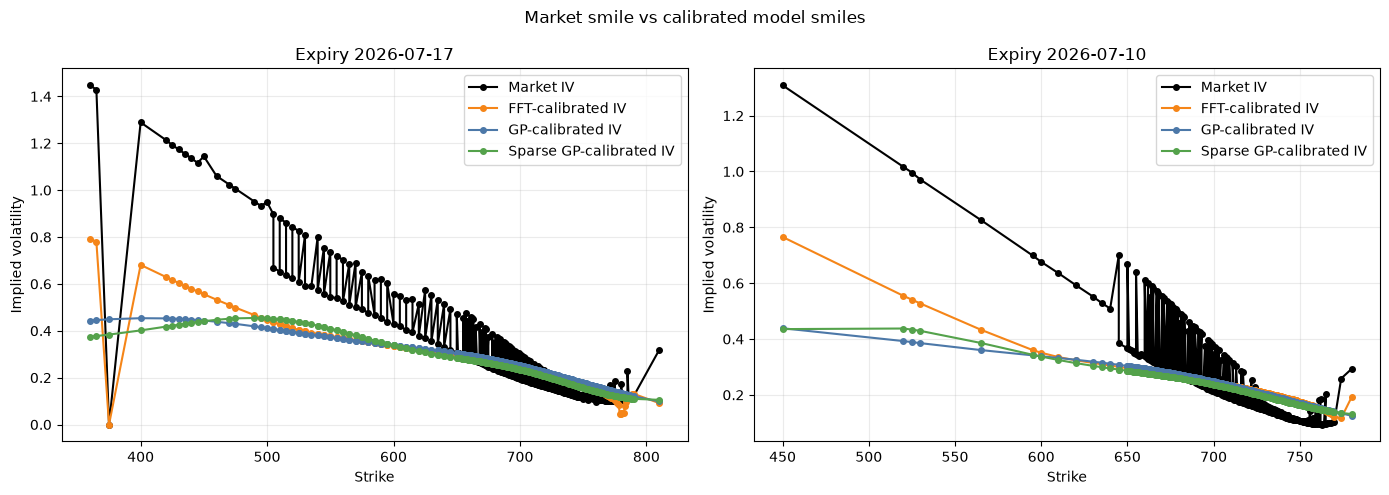

Plotted expiries: 2026-07-17, 2026-07-10
Saved plot to outputs/calibration_comparison_3/smile_comparison.png


In [8]:
# Merge predictions so the market, FFT, GP, and Sparse GP IVs use the same contracts.
plot_data = gp_predictions[[
    "contractSymbol",
    "expiry",
    "strike",
    "market_iv",
    "gp_predicted_iv",
]].merge(
    fft_predictions[["contractSymbol", "fft_predicted_iv"]],
    on="contractSymbol",
    how="inner",
).merge(
    sparse_gp_predictions[["contractSymbol", "sparse_gp_predicted_iv"]],
    on="contractSymbol",
    how="inner",
)
plot_data = plot_data.dropna(
    subset=["market_iv", "gp_predicted_iv", "fft_predicted_iv", "sparse_gp_predicted_iv"]
)

# Plot the two expiries with the most complete smiles.
selected_expiries = plot_data["expiry"].value_counts().head(2).index.tolist()
fig, axes = plt.subplots(1, len(selected_expiries), figsize=(7 * len(selected_expiries), 5), squeeze=False)

for ax, expiry in zip(axes.ravel(), selected_expiries):
    smile = plot_data.loc[plot_data["expiry"] == expiry].sort_values("strike")
    ax.plot(smile["strike"], smile["market_iv"], "o-", label="Market IV", color="black", linewidth=1.5, markersize=4)
    ax.plot(smile["strike"], smile["fft_predicted_iv"], "o-", label="FFT-calibrated IV", color="#F58518", linewidth=1.5, markersize=4)
    ax.plot(smile["strike"], smile["gp_predicted_iv"], "o-", label="GP-calibrated IV", color="#4C78A8", linewidth=1.5, markersize=4)
    ax.plot(smile["strike"], smile["sparse_gp_predicted_iv"], "o-", label="Sparse GP-calibrated IV", color="#54A24B", linewidth=1.5, markersize=4)
    ax.set_title(f"Expiry {expiry}")
    ax.set_xlabel("Strike")
    ax.set_ylabel("Implied volatility")
    ax.grid(True, alpha=0.25)
    ax.legend()

fig.suptitle("Market smile vs calibrated model smiles")
fig.tight_layout()

smile_plot_path = OUTPUT_DIR / "smile_comparison.png"
fig.savefig(smile_plot_path, dpi=180)
plt.show()

print(f"Plotted expiries: {', '.join(selected_expiries)}")
print(f"Saved plot to {smile_plot_path}")

## Fit Quality Discussion

In [9]:
# Compare aggregate error across the three methods and the visual smile fit.
rmse_by_method = {
    "FFT": float(fft_summary["rmse"]),
    "GP": float(gp_summary["rmse"]),
    "Sparse GP": float(sparse_gp_summary["rmse"]),
}
best_method = min(rmse_by_method, key=rmse_by_method.get)
sorted_rmse = sorted(rmse_by_method.values())
runner_up_gap = sorted_rmse[1] - sorted_rmse[0]

print(
    f"The {best_method} calibration has the lowest RMSE ({rmse_by_method[best_method]:.4f}), "
    f"ahead of the next-best method by {runner_up_gap:.4f}. "
    "The smile plots show whether that aggregate difference comes from a broad improvement "
    "across strikes or from a few contracts in the wings."
)

The FFT calibration has the lowest RMSE (0.1347), ahead of the next-best method by 0.0144. The smile plots show whether that aggregate difference comes from a broad improvement across strikes or from a few contracts in the wings.


## 3 Runtime Comparison

In [10]:
# Speedup is each method's time relative to the GP time. Values above 1 mean faster than GP.
fft_time = float(fft_summary["wall_clock_seconds"])
gp_time = float(gp_summary["wall_clock_seconds"])
sparse_gp_time = float(sparse_gp_summary["wall_clock_seconds"])

time_table = pd.DataFrame([
    {"method": "FFT pricer", "wall_clock_seconds": fft_time, "speedup_vs_gp": gp_time / fft_time},
    {"method": "GP emulator", "wall_clock_seconds": gp_time, "speedup_vs_gp": 1.0},
    {"method": "Sparse GP emulator", "wall_clock_seconds": sparse_gp_time, "speedup_vs_gp": gp_time / sparse_gp_time},
])

time_table.to_csv(OUTPUT_DIR / "time_comparison.csv", index=False)
time_table

,method,wall_clock_seconds,speedup_vs_gp
0,FFT pricer,3.495879,1.111004
1,GP emulator,3.883935,1.000000
2,Sparse GP emulator,3.263193,1.190225


## Runtime Visualization

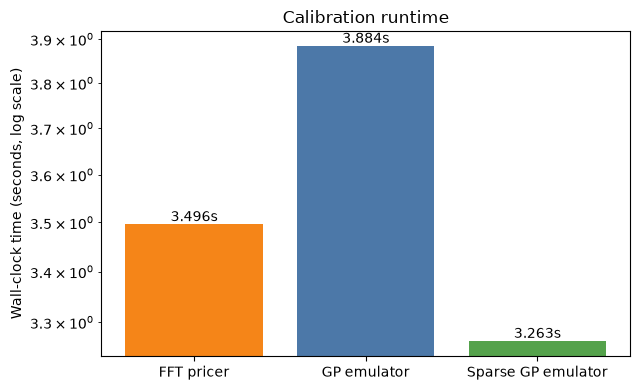

Saved plot to outputs/calibration_comparison_3/runtime_comparison.png


In [11]:
# Show elapsed calibration time directly; log scale helps when the gap is large.
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(time_table["method"], time_table["wall_clock_seconds"], color=["#F58518", "#4C78A8", "#54A24B"])
ax.set_yscale("log")
ax.set_ylabel("Wall-clock time (seconds, log scale)")
ax.set_title("Calibration runtime")
ax.grid(axis="y", alpha=0.25)

for i, row in enumerate(time_table.itertuples(index=False)):
    ax.text(i, row.wall_clock_seconds, f"{row.wall_clock_seconds:.3f}s", ha="center", va="bottom")

fig.tight_layout()
runtime_plot_path = OUTPUT_DIR / "runtime_comparison.png"
fig.savefig(runtime_plot_path, dpi=180)
plt.show()

print(f"Saved plot to {runtime_plot_path}")

## Runtime Discussion

In [12]:
# Interpret elapsed time directly from the saved calibration summaries.
time_by_method = {
    "FFT": float(fft_summary["wall_clock_seconds"]),
    "GP": float(gp_summary["wall_clock_seconds"]),
    "Sparse GP": float(sparse_gp_summary["wall_clock_seconds"]),
}
fastest_method = min(time_by_method, key=time_by_method.get)
slowest_method = max(time_by_method, key=time_by_method.get)
ratio = time_by_method[slowest_method] / time_by_method[fastest_method]

print(
    f"{fastest_method} was the fastest calibration ({time_by_method[fastest_method]:.2f}s), and "
    f"{slowest_method} was the slowest at {ratio:.2f}x that time. "
    "These times include optimizer behavior, so they reflect the full calibration workflow rather than one model evaluation."
)

Sparse GP was the fastest calibration (3.26s), and GP was the slowest at 1.19x that time. These times include optimizer behavior, so they reflect the full calibration workflow rather than one model evaluation.


## Efficiency Plot

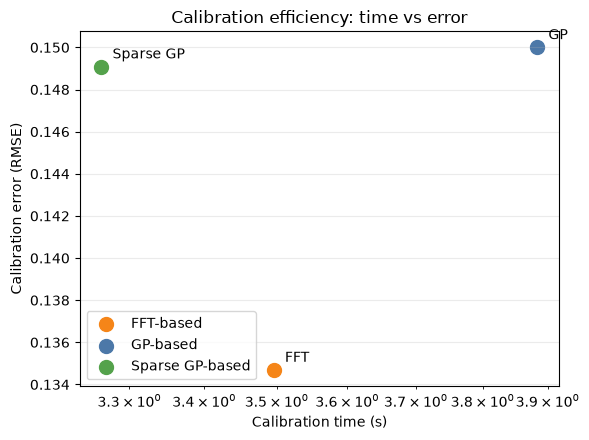

Saved plot to outputs/calibration_comparison_3/efficiency_time_vs_error.png


In [13]:
# Put speed and fit quality in one view.
fft_error = float(fft_summary["rmse"])
gp_error = float(gp_summary["rmse"])
sparse_gp_error = float(sparse_gp_summary["rmse"])

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter([fft_time], [fft_error], label="FFT-based", s=100, color="#F58518")
ax.scatter([gp_time], [gp_error], label="GP-based", s=100, color="#4C78A8")
ax.scatter([sparse_gp_time], [sparse_gp_error], label="Sparse GP-based", s=100, color="#54A24B")
ax.set_xscale("log")
ax.set_xlabel("Calibration time (s)")
ax.set_ylabel("Calibration error (RMSE)")
ax.set_title("Calibration efficiency: time vs error")
ax.grid(True, alpha=0.25)
ax.legend()

for label, x, y in [
    ("FFT", fft_time, fft_error),
    ("GP", gp_time, gp_error),
    ("Sparse GP", sparse_gp_time, sparse_gp_error),
]:
    ax.annotate(label, (x, y), textcoords="offset points", xytext=(8, 6))

fig.tight_layout()
efficiency_plot_path = OUTPUT_DIR / "efficiency_time_vs_error.png"
fig.savefig(efficiency_plot_path, dpi=180)
plt.show()

print(f"Saved plot to {efficiency_plot_path}")

## Efficiency Discussion

In [14]:
# Tie fit quality and runtime together in one conclusion across the three methods.
errors = {"FFT": fft_error, "GP": gp_error, "Sparse GP": sparse_gp_error}
times = {"FFT": fft_time, "GP": gp_time, "Sparse GP": sparse_gp_time}

most_accurate = min(errors, key=errors.get)
fastest = min(times, key=times.get)

if most_accurate == fastest:
    conclusion = f"{most_accurate} dominates here: lowest RMSE and fastest runtime."
else:
    conclusion = (
        f"{most_accurate} is the most accurate (lowest RMSE), while {fastest} is the fastest, "
        "so the best choice depends on whether accuracy or speed matters more."
    )

print(
    conclusion
    + " The time-vs-error scatter is the clearest single view of this tradeoff."
)

FFT is the most accurate (lowest RMSE), while Sparse GP is the fastest, so the best choice depends on whether accuracy or speed matters more. The time-vs-error scatter is the clearest single view of this tradeoff.
